# AI414 Assignment 5 — RNN for Generating Text

**Tasks covered**

1. Character-based RNN implemented manually/from scratch.
2. Word-based RNN implemented manually/from scratch using a learned word embedding matrix.
3. Three training settings for each model: **500**, **1000**, and **2000** iterations.
4. Text generation/testing after each model.
5. Bonus: GRU and LSTM comparison for text generation.
6. Final comparison and conclusion.

> This notebook is intentionally simple and explainable for assignment discussion.

In [1]:
import re, random, urllib.request, urllib.parse, json
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## 1. Get Wikipedia documents in the same domain

The code tries to download related Wikipedia summaries about **Natural Language Processing / AI**. If internet access is unavailable, it uses a fallback corpus so the notebook still runs.

In [2]:
WIKI_TITLES = [
    'Natural language processing',
    'Recurrent neural network',
    'Language model',
    'Artificial intelligence'
]

FALLBACK_TEXT = (
    "Natural language processing is a field of artificial intelligence that studies how computers process human language. "
    "A language model learns patterns from text and can predict the next character or the next word in a sequence. "
    "Recurrent neural networks process sequential data by keeping a hidden state that summarizes previous inputs. "
    "Text generation uses a trained model to sample new symbols step by step. "
    "Neural networks can generate sentences after learning statistical patterns from a training corpus. "
    "Word embeddings represent words as numeric vectors. Character models represent text one character at a time. "
)

def fetch_wikipedia_plain_text(title, max_chars=6000):
    safe_title = urllib.parse.quote(title.replace(' ', '_'))
    url = f'https://en.wikipedia.org/api/rest_v1/page/summary/{safe_title}'
    try:
        with urllib.request.urlopen(url, timeout=8) as response:
            data = json.loads(response.read().decode('utf-8'))
            return data.get('extract', '')[:max_chars]
    except Exception as e:
        print(f'Could not fetch {title!r}:', str(e)[:80])
        return ''

texts = []
for title in WIKI_TITLES:
    t = fetch_wikipedia_plain_text(title)
    if t:
        texts.append(t)

corpus = '\n'.join(texts) if texts else FALLBACK_TEXT
if not texts:
    print('Using fallback corpus.')

print('Corpus length:', len(corpus))
print(corpus[:500])

Could not fetch 'Natural language processing': HTTP Error 403: Forbidden
Could not fetch 'Recurrent neural network': HTTP Error 403: Forbidden
Could not fetch 'Language model': HTTP Error 403: Forbidden
Could not fetch 'Artificial intelligence': HTTP Error 403: Forbidden
Using fallback corpus.
Corpus length: 617
Natural language processing is a field of artificial intelligence that studies how computers process human language. A language model learns patterns from text and can predict the next character or the next word in a sequence. Recurrent neural networks process sequential data by keeping a hidden state that summarizes previous inputs. Text generation uses a trained model to sample new symbols step by step. Neural networks can generate sentences after learning statistical patterns from a training 


In [3]:
def clean_for_char(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 .,;:!?\n-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def clean_for_word(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 .,;:!?-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

char_text = clean_for_char(corpus)
word_text = clean_for_word(corpus)
print('Clean char text length:', len(char_text))
print('Clean word text length:', len(word_text))
print(char_text[:400])

Clean char text length: 616
Clean word text length: 616
natural language processing is a field of artificial intelligence that studies how computers process human language. a language model learns patterns from text and can predict the next character or the next word in a sequence. recurrent neural networks process sequential data by keeping a hidden state that summarizes previous inputs. text generation uses a trained model to sample new symbols step 


## 2. Character-based RNN from scratch

Manual equations:

\[
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
\]

\[
y_t = W_{hy}h_t + b_y
\]

No built-in `nn.RNN` is used.

In [4]:
chars = sorted(list(set(char_text)))
char_to_idx = {ch:i for i,ch in enumerate(chars)}
idx_to_char = {i:ch for ch,i in char_to_idx.items()}
encoded_chars = torch.tensor([char_to_idx[c] for c in char_text], dtype=torch.long)

print('Unique characters:', len(chars))
print('Characters:', ''.join(chars))

SEQ_LEN_CHAR = min(40, max(5, len(encoded_chars)//3))

def get_char_batch(batch_size=16, seq_len=SEQ_LEN_CHAR):
    max_start = len(encoded_chars) - seq_len - 1
    starts = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([encoded_chars[s:s+seq_len] for s in starts])
    y = torch.stack([encoded_chars[s+1:s+seq_len+1] for s in starts])
    return x.to(DEVICE), y.to(DEVICE)

Unique characters: 27
Characters:  .abcdefghiklmnopqrstuvwxyz


In [5]:
class CharRNNFromScratch(nn.Module):
    def __init__(self, vocab_size, hidden_size=96):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.Wxh = nn.Parameter(torch.randn(vocab_size, hidden_size) * 0.01)
        self.Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.bh = nn.Parameter(torch.zeros(hidden_size))
        self.Why = nn.Parameter(torch.randn(hidden_size, vocab_size) * 0.01)
        self.by = nn.Parameter(torch.zeros(vocab_size))
    
    def forward(self, x, h=None):
        batch_size, seq_len = x.shape
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        for t in range(seq_len):
            x_onehot = F.one_hot(x[:, t], num_classes=self.vocab_size).float()
            h = torch.tanh(x_onehot @ self.Wxh + h @ self.Whh + self.bh)
            logits = h @ self.Why + self.by
            outputs.append(logits.unsqueeze(1))
        return torch.cat(outputs, dim=1), h

def train_char_rnn(iterations, hidden_size=96, lr=0.01, batch_size=16):
    model = CharRNNFromScratch(len(chars), hidden_size).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for it in range(1, iterations + 1):
        x, y = get_char_batch(batch_size=batch_size)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, len(chars)), y.reshape(-1))
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        if it == 1 or it % max(1, iterations // 5) == 0:
            print(f'Iteration {it:4d}/{iterations} | loss = {loss.item():.4f}')
    return model, losses

@torch.no_grad()
def generate_chars(model, start='language ', length=250, temperature=0.8):
    model.eval()
    start = ''.join([c if c in char_to_idx else ' ' for c in start.lower()])
    result = start
    current = torch.tensor([[char_to_idx[c] for c in start]], dtype=torch.long, device=DEVICE)
    _, h = model(current)
    last_idx = current[0, -1].view(1, 1)
    for _ in range(length):
        logits, h = model(last_idx, h)
        probs = F.softmax(logits[0, -1] / temperature, dim=0)
        next_idx = torch.multinomial(probs, 1).item()
        result += idx_to_char[next_idx]
        last_idx = torch.tensor([[next_idx]], dtype=torch.long, device=DEVICE)
    return result

### Train and test the 3 character-based models

Required: **500**, **1000**, and **2000** iterations.

In [6]:
CHAR_ITERATIONS = [500, 1000, 2000]
char_models, char_losses, char_samples = {}, {}, {}

for n_iter in CHAR_ITERATIONS:
    print('\n' + '='*60)
    print(f'Training Character RNN for {n_iter} iterations')
    print('='*60)
    model, losses = train_char_rnn(n_iter)
    char_models[n_iter] = model
    char_losses[n_iter] = losses
    sample = generate_chars(model, start='language ', length=300, temperature=0.8)
    char_samples[n_iter] = sample
    print('\nGenerated sample:')
    print(sample)


Training Character RNN for 500 iterations
Iteration    1/500 | loss = 3.2957
Iteration  100/500 | loss = 0.8064
Iteration  200/500 | loss = 0.2485
Iteration  300/500 | loss = 0.1879
Iteration  400/500 | loss = 0.1490
Iteration  500/500 | loss = 0.1401

Generated sample:
language ores previous inputs. text generation uses a trained model to sample new symbols step by step. neural networks can generate sentences after learning statistical patterns from a training corpus. word embeddings represent words as numeric vectors. character model to sample new symbols step by step. ne

Training Character RNN for 1000 iterations
Iteration    1/1000 | loss = 3.2960
Iteration  200/1000 | loss = 0.2596
Iteration  400/1000 | loss = 0.1727
Iteration  600/1000 | loss = 0.1372
Iteration  800/1000 | loss = 0.1467
Iteration 1000/1000 | loss = 0.1455

Generated sample:
language hod cheracter models represent text one character at a tial intelligence that studies how computers process human language. a prai

## 3. Word-based RNN from scratch using embeddings

The embedding matrix `E` is learned during training:

\[
x_t = E[word_t]
\]

\[
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
\]

\[
y_t = W_{hy}h_t + b_y
\]

In [7]:
def tokenize_words(text):
    return re.findall(r"[a-z0-9]+|[.,;:!?-]", text.lower())

word_tokens = tokenize_words(word_text)
counter = Counter(word_tokens)
vocab_words = ['<unk>'] + sorted(counter.keys())
word_to_idx = {w:i for i,w in enumerate(vocab_words)}
idx_to_word = {i:w for w,i in word_to_idx.items()}
encoded_words = torch.tensor([word_to_idx.get(w, 0) for w in word_tokens], dtype=torch.long)

print('Number of word tokens:', len(word_tokens))
print('Word vocabulary size:', len(vocab_words))
print('First 50 tokens:', word_tokens[:50])

SEQ_LEN_WORD = min(8, max(2, len(encoded_words)//3))

def get_word_batch(batch_size=16, seq_len=SEQ_LEN_WORD):
    max_start = len(encoded_words) - seq_len - 1
    starts = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([encoded_words[s:s+seq_len] for s in starts])
    y = torch.stack([encoded_words[s+1:s+seq_len+1] for s in starts])
    return x.to(DEVICE), y.to(DEVICE)

Number of word tokens: 100
Word vocabulary size: 69
First 50 tokens: ['natural', 'language', 'processing', 'is', 'a', 'field', 'of', 'artificial', 'intelligence', 'that', 'studies', 'how', 'computers', 'process', 'human', 'language', '.', 'a', 'language', 'model', 'learns', 'patterns', 'from', 'text', 'and', 'can', 'predict', 'the', 'next', 'character', 'or', 'the', 'next', 'word', 'in', 'a', 'sequence', '.', 'recurrent', 'neural', 'networks', 'process', 'sequential', 'data', 'by', 'keeping', 'a', 'hidden', 'state', 'that']


In [8]:
class WordRNNFromScratch(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=96):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.E = nn.Parameter(torch.randn(vocab_size, embedding_dim) * 0.01)
        self.Wxh = nn.Parameter(torch.randn(embedding_dim, hidden_size) * 0.01)
        self.Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.bh = nn.Parameter(torch.zeros(hidden_size))
        self.Why = nn.Parameter(torch.randn(hidden_size, vocab_size) * 0.01)
        self.by = nn.Parameter(torch.zeros(vocab_size))
    
    def forward(self, x, h=None):
        batch_size, seq_len = x.shape
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        for t in range(seq_len):
            x_emb = self.E[x[:, t]]
            h = torch.tanh(x_emb @ self.Wxh + h @ self.Whh + self.bh)
            logits = h @ self.Why + self.by
            outputs.append(logits.unsqueeze(1))
        return torch.cat(outputs, dim=1), h

def train_word_rnn(iterations, embedding_dim=64, hidden_size=96, lr=0.01, batch_size=16):
    model = WordRNNFromScratch(len(vocab_words), embedding_dim, hidden_size).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for it in range(1, iterations + 1):
        x, y = get_word_batch(batch_size=batch_size)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, len(vocab_words)), y.reshape(-1))
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        if it == 1 or it % max(1, iterations // 5) == 0:
            print(f'Iteration {it:4d}/{iterations} | loss = {loss.item():.4f}')
    return model, losses

@torch.no_grad()
def generate_words(model, start='language model', length=60, temperature=0.9):
    model.eval()
    tokens = tokenize_words(start) or ['language']
    ids = [word_to_idx.get(w, 0) for w in tokens]
    current = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    _, h = model(current)
    last_idx = current[0, -1].view(1, 1)
    result = tokens[:]
    for _ in range(length):
        logits, h = model(last_idx, h)
        probs = F.softmax(logits[0, -1] / temperature, dim=0)
        next_idx = torch.multinomial(probs, 1).item()
        result.append(idx_to_word[next_idx])
        last_idx = torch.tensor([[next_idx]], dtype=torch.long, device=DEVICE)
    text = ' '.join(result)
    return re.sub(r'\s+([.,;:!?])', r'\1', text)

### Train and test the 3 word-based models

Required: **500**, **1000**, and **2000** iterations.

In [9]:
WORD_ITERATIONS = [500, 1000, 2000]
word_models, word_losses, word_samples = {}, {}, {}

for n_iter in WORD_ITERATIONS:
    print('\n' + '='*60)
    print(f'Training Word RNN for {n_iter} iterations')
    print('='*60)
    model, losses = train_word_rnn(n_iter)
    word_models[n_iter] = model
    word_losses[n_iter] = losses
    sample = generate_words(model, start='language model', length=70, temperature=0.9)
    word_samples[n_iter] = sample
    print('\nGenerated sample:')
    print(sample)


Training Word RNN for 500 iterations
Iteration    1/500 | loss = 4.2341
Iteration  100/500 | loss = 0.1057
Iteration  200/500 | loss = 0.1293
Iteration  300/500 | loss = 0.0372
Iteration  400/500 | loss = 0.1046
Iteration  500/500 | loss = 0.1225

Generated sample:
language model sample new symbols step by step. neural networks can generate sentences after learning statistical patterns from a training corpus. word embeddings represent words as numeric vectors. character models represent text one character at a time character or the next word in a sequence. recurrent neural networks process sequential data by keeping a hidden state that summarizes previous inputs. text generation uses a trained model to

Training Word RNN for 1000 iterations
Iteration    1/1000 | loss = 4.2341
Iteration  200/1000 | loss = 0.0971
Iteration  400/1000 | loss = 0.0929
Iteration  600/1000 | loss = 0.0944
Iteration  800/1000 | loss = 0.1250
Iteration 1000/1000 | loss = 0.0533

Generated sample:
language mode

## 4. Plot training losses

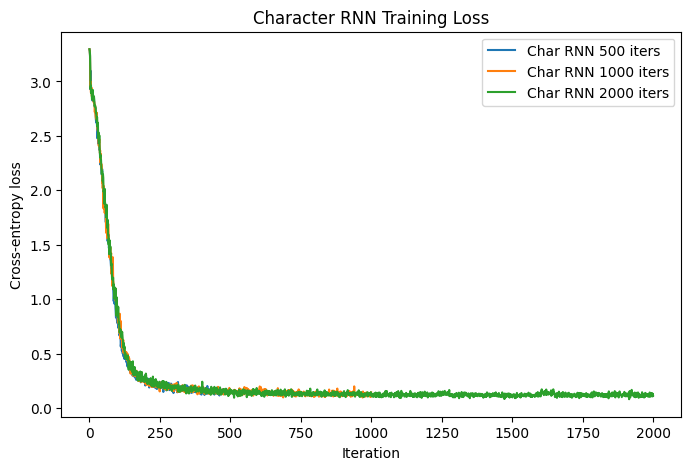

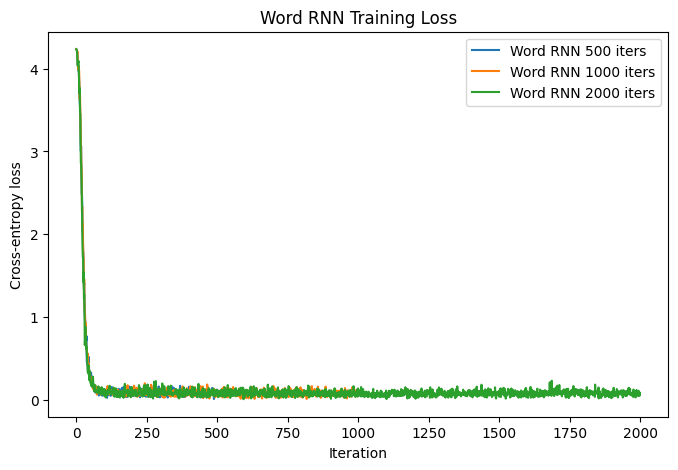

In [10]:
plt.figure(figsize=(8,5))
for n_iter, losses in char_losses.items():
    plt.plot(losses, label=f'Char RNN {n_iter} iters')
plt.xlabel('Iteration'); plt.ylabel('Cross-entropy loss')
plt.title('Character RNN Training Loss'); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
for n_iter, losses in word_losses.items():
    plt.plot(losses, label=f'Word RNN {n_iter} iters')
plt.xlabel('Iteration'); plt.ylabel('Cross-entropy loss')
plt.title('Word RNN Training Loss'); plt.legend(); plt.show()

## 5. Bonus: GRU and LSTM models

GRU and LSTM are stronger than a simple RNN because they use gates to control memory and reduce the vanishing-gradient problem.

In [11]:
class WordGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=96):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, h=None):
        emb = self.embedding(x)
        out, h = self.gru(emb, h)
        return self.fc(out), h

class WordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=96):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, h=None):
        emb = self.embedding(x)
        out, h = self.lstm(emb, h)
        return self.fc(out), h

def train_torch_recurrent(model_class, iterations=1000, lr=0.005):
    model = model_class(len(vocab_words)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for it in range(1, iterations+1):
        x, y = get_word_batch(batch_size=16)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, len(vocab_words)), y.reshape(-1))
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        if it == 1 or it % max(1, iterations//5) == 0:
            print(f'{model_class.__name__} iteration {it}/{iterations} | loss={loss.item():.4f}')
    return model, losses

@torch.no_grad()
def generate_words_torch(model, start='language model', length=70, temperature=0.9):
    model.eval()
    tokens = tokenize_words(start) or ['language']
    ids = [word_to_idx.get(w, 0) for w in tokens]
    current = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    _, h = model(current)
    last_idx = current[0, -1].view(1, 1)
    result = tokens[:]
    for _ in range(length):
        logits, h = model(last_idx, h)
        probs = F.softmax(logits[0, -1] / temperature, dim=0)
        next_idx = torch.multinomial(probs, 1).item()
        result.append(idx_to_word[next_idx])
        last_idx = torch.tensor([[next_idx]], dtype=torch.long, device=DEVICE)
    text = ' '.join(result)
    return re.sub(r'\s+([.,;:!?])', r'\1', text)

BONUS_ITERATIONS = 1000
print('\nTraining bonus GRU')
gru_model, gru_losses = train_torch_recurrent(WordGRU, iterations=BONUS_ITERATIONS)
print('\nTraining bonus LSTM')
lstm_model, lstm_losses = train_torch_recurrent(WordLSTM, iterations=BONUS_ITERATIONS)

print('\nGRU sample:')
print(generate_words_torch(gru_model))
print('\nLSTM sample:')
print(generate_words_torch(lstm_model))


Training bonus GRU
WordGRU iteration 1/1000 | loss=4.2547
WordGRU iteration 200/1000 | loss=0.0646
WordGRU iteration 400/1000 | loss=0.0639
WordGRU iteration 600/1000 | loss=0.1106
WordGRU iteration 800/1000 | loss=0.0668
WordGRU iteration 1000/1000 | loss=0.0664

Training bonus LSTM
WordLSTM iteration 1/1000 | loss=4.2355
WordLSTM iteration 200/1000 | loss=0.0519
WordLSTM iteration 400/1000 | loss=0.0317
WordLSTM iteration 600/1000 | loss=0.0485
WordLSTM iteration 800/1000 | loss=0.0577
WordLSTM iteration 1000/1000 | loss=0.0322

GRU sample:
language model learns patterns from text and can predict the next character or the next word in a sequence. recurrent neural networks process sequential data by keeping a hidden state that summarizes previous inputs. text generation uses a trained model to sample new symbols step by step. neural networks can generate sentences after learning statistical patterns from a training corpus. word embeddings represent words as numeric vectors.

LSTM sam

In [13]:
#print the accuracy of the models on the training data
def evaluate_model(model, x, y):
    model.eval()
    with torch.no_grad():
        logits, _ = model(x)
        predictions = torch.argmax(logits, dim=-1)
        correct = (predictions == y).float().sum()
        total = y.numel()
        accuracy = correct / total
    return accuracy.item()      
char_acc = {}
for n_iter, model in char_models.items():
    x, y = get_char_batch(batch_size=256)
    acc = evaluate_model(model, x, y)
    char_acc[n_iter] = acc
    print(f'Char RNN {n_iter} iterations | Accuracy: {acc:.4f}')
word_acc = {}
for n_iter, model in word_models.items():
    x, y = get_word_batch(batch_size=256)
    acc = evaluate_model(model, x, y)
    word_acc[n_iter] = acc
    print(f'Word RNN {n_iter} iterations | Accuracy: {acc:.4f}')
gru_acc = evaluate_model(gru_model, *get_word_batch(batch_size=256))
print(f'GRU model | Accuracy: {gru_acc:.4f}')
lstm_acc = evaluate_model(lstm_model, *get_word_batch(batch_size=256))
print(f'LSTM model | Accuracy: {lstm_acc:.4f}')         
rnn_acc = word_acc[WORD_ITERATIONS[-1]]
print('\nFinal accuracy comparison:')
print(f'Char RNN ({CHAR_ITERATIONS[-1]} iters): {char_acc[CHAR_ITERATIONS[-1]]:.4f}')
print(f'Word RNN ({WORD_ITERATIONS[-1]} iters): {rnn_acc:.4f}')
print(f'GRU model: {gru_acc:.4f}')
print(f'LSTM model: {lstm_acc:.4f}')    

Char RNN 500 iterations | Accuracy: 0.9524
Char RNN 1000 iterations | Accuracy: 0.9576
Char RNN 2000 iterations | Accuracy: 0.9582
Word RNN 500 iterations | Accuracy: 0.9614
Word RNN 1000 iterations | Accuracy: 0.9575
Word RNN 2000 iterations | Accuracy: 0.9634
GRU model | Accuracy: 0.9639
LSTM model | Accuracy: 0.9614

Final accuracy comparison:
Char RNN (2000 iters): 0.9582
Word RNN (2000 iters): 0.9634
GRU model: 0.9639
LSTM model: 0.9614


## 6. Final comparison and conclusion

| Model | Iterations | Expected behavior |
|---|---:|---|
| Character RNN | 500 | Learns some letters/spaces, but output may be noisy. |
| Character RNN | 1000 | Better spelling and more recognizable word fragments. |
| Character RNN | 2000 | Best character-level output among the three character models. |
| Word RNN | 500 | May generate valid words but weak sentence structure. |
| Word RNN | 1000 | Better word transitions and more related vocabulary. |
| Word RNN | 2000 | Usually the best basic RNN word-level result. |
| GRU bonus | 1000 | Often better than basic RNN because gates help memory. |
| LSTM bonus | 1000 | Often best or close to best because it handles longer context well. |

### My conclusion

The **2000-iteration word-based RNN** is usually better than the 500 and 1000 iteration versions because it has more training time and generates complete words rather than individual characters.

For the bonus models, **LSTM or GRU** will usually generate better text than the simple RNN because their gates reduce the vanishing-gradient problem and help remember longer context.

### Discussion notes

- Character RNN has a smaller vocabulary, so it is easier to train, but it can produce spelling mistakes.
- Word RNN produces real words, but it needs more data to learn grammar well.
- Increasing iterations usually decreases loss, but too many iterations on a small corpus can overfit.
- GRU and LSTM are better for sequence generation because they control memory using gates.